# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [33]:
# Replace None with your code
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
# Create connection to database
conn = sqlite3.connect('data.sqlite')

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [34]:
california_higher_credit = pd.read_sql("""
SELECT customerName,
       city,
       state,
       country,
       creditLimit
FROM customers
WHERE state = 'CA'
  AND creditLimit > 25000
ORDER BY creditLimit DESC;
""", conn)

california_higher_credit


,customerName,city,state,country,creditLimit
0,Toys4GrownUps.com,Pasadena,CA,USA,90700.00
1,Technics Stores Inc.,Burlingame,CA,USA,84600.00
2,The Sharp Gifts Warehouse,San Jose,CA,USA,77600.00
3,Mini Wheels Co.,San Francisco,CA,USA,64600.00
4,Signal Collectibles Ltd.,Brisbane,CA,USA,60300.00
5,"Men 'R' US Retailers, Ltd.",Los Angeles,CA,USA,57700.00
6,West Coast Collectables Co.,Burbank,CA,USA,55400.00
7,Mini Gifts Distributors Ltd.,San Rafael,CA,USA,210500.00
8,Boards & Toys Co.,Glendale,CA,USA,11000.00
9,Collectable Mini Designs Co.,San Diego,CA,USA,105000.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [35]:
# Replace None with your code
International_collectors = pd.read_sql("""
SELECT customerName,
       city,
       country,
       creditLimit
FROM customers
WHERE country != 'USA'
  AND creditLimit > 25000
ORDER BY creditLimit DESC;
""", conn)

International_collectors


,customerName,city,country,creditLimit
0,Suominen Souveniers,Espoo,Finland,98800.00
1,Handji Gifts& Co,Singapore,Singapore,97900.00
2,Herkku Gifts,Bergen,Norway,96800.00
3,"Toys of Finland, Co.",Helsinki,Finland,96500.00
4,"Norway Gifts By Mail, Co.",Oslo,Norway,95100.00
...,...,...,...,...
81,Warburg Exchange,Aachen,Germany,0.00
82,"Anton Designs, Ltd.",Madrid,Spain,0.00
83,Mit Vergnügen & Co.,Mannheim,Germany,0.00
84,"Kremlin Collectables, Co.",Saint Petersburg,Russia,0.00


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [36]:
USA_credit_policy = pd.read_sql("""
SELECT
         state,
        AVG(CAST(creditLimit AS DECIMAL)) AS average_credit_limit
FROM customers
WHERE country = 'USA'
GROUP BY state
ORDER BY average_credit_limit DESC
""", conn)
USA_credit_policy

,state,average_credit_limit
0,NH,114200.000000
1,NY,89966.666667
2,PA,84766.666667
3,CA,83854.545455
4,NV,71800.000000
5,MA,70755.555556
6,CT,57350.000000
7,NJ,43000.000000


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

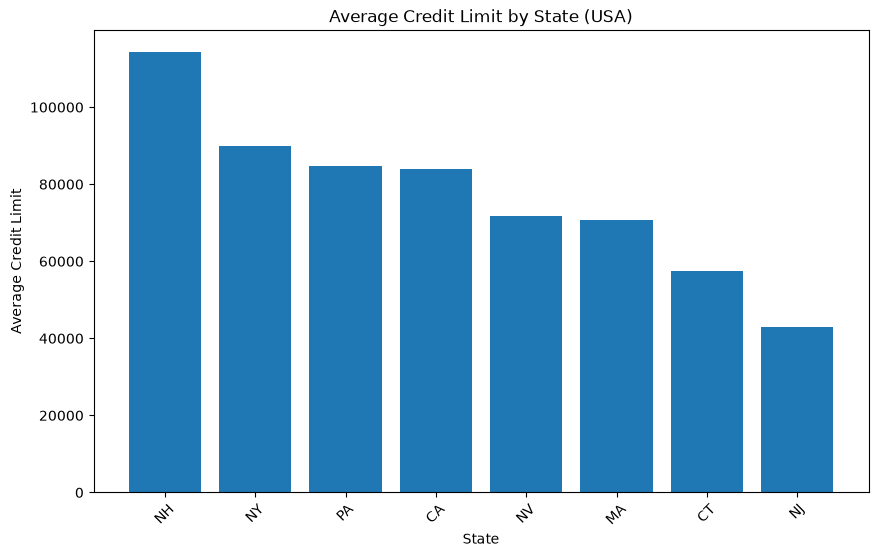

In [37]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(USA_credit_policy['state'], USA_credit_policy['average_credit_limit'])
plt.xlabel('State')
plt.ylabel('Average Credit Limit')
plt.title('Average Credit Limit by State (USA)')
plt.xticks(rotation=45)
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [38]:
# Replace None with your code
Top_customers = pd.read_sql("""
SELECT c.customerName,SUM(CAST(P.AMOUNT AS DECIMAL(10,2))) AS total_payments
                            from customers c
                            JOIN payments P ON c.customerNumber = P.customerNumber
                            GROUP BY c.customerName
                            ORDER BY total_payments DESC
                            LIMIT 10
""", conn)
Top_customers

,customerName,total_payments
0,Euro+ Shopping Channel,715738.98
1,Mini Gifts Distributors Ltd.,584188.24
2,"Australian Collectors, Co.",180585.07
3,Muscle Machine Inc,177913.95
4,"Dragon Souveniers, Ltd.",156251.03
5,"Down Under Souveniers, Inc",154622.08
6,"AV Stores, Co.",148410.09
7,"Anna's Decorations, Ltd",137034.22
8,Corporate Gift Ideas Co.,132340.78
9,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

Text(0, 0.5, 'Customer Name')

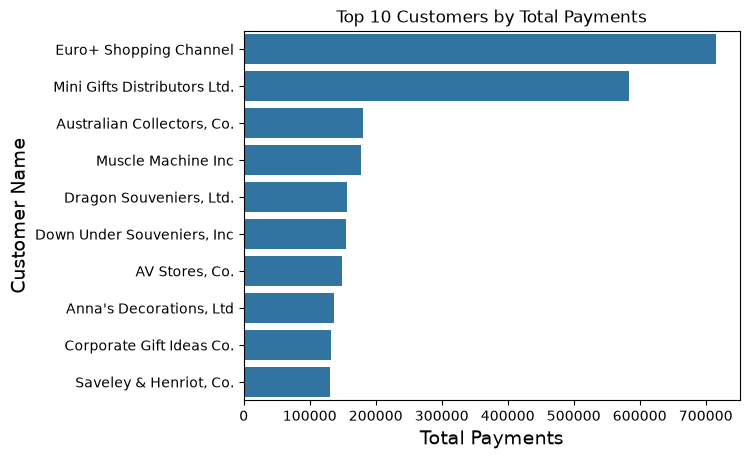

In [39]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments
sns.barplot(
    x='total_payments',
      y='customerName', 
      data=Top_customers)
plt.title('Top 10 Customers by Total Payments')
plt.xlabel('Total Payments', fontsize=14)
plt.ylabel('Customer Name', fontsize=14)

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [40]:
# Replace None with you code
Top_customer_by_product_Quantities = pd.read_sql("""
SELECT 
c.customerName,
c.customerNumber,
od.productCode,
SUM(od.quantityOrdered) AS total_quantity_ordered
 FROM customers c
JOIN orders o ON c.customerNumber = o.customerNumber
JOIN orderdetails od ON o.orderNumber = od.orderNumber
GROUP BY c.customerName, c.customerNumber, od.productCode
ORDER BY total_quantity_ordered DESC
LIMIT 10
""", conn)
Top_customer_by_product_Quantities

,customerName,customerNumber,productCode,total_quantity_ordered
0,Euro+ Shopping Channel,141,S18_3232,308
1,Euro+ Shopping Channel,141,S24_2840,245
2,Euro+ Shopping Channel,141,S24_1444,197
3,Euro+ Shopping Channel,141,S12_4473,183
4,Euro+ Shopping Channel,141,S24_3432,174
5,Mini Gifts Distributors Ltd.,124,S18_4668,167
6,Euro+ Shopping Channel,141,S24_3856,161
7,Euro+ Shopping Channel,141,S24_4048,161
8,Euro+ Shopping Channel,141,S24_2766,158
9,Euro+ Shopping Channel,141,S32_2509,157


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [41]:
# Replace None with your code
products_line_analysis = pd.read_sql("""
SELECT 
    p.productLine,
    COUNT(DISTINCT p.productCode) AS total_products,
    SUM(od.quantityOrdered) AS total_quantity_ordered
FROM products p
JOIN orderdetails od 
    ON p.productCode = od.productCode
GROUP BY p.productLine
ORDER BY total_quantity_ordered DESC;
""", conn)

products_line_analysis


,productLine,total_products,total_quantity_ordered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

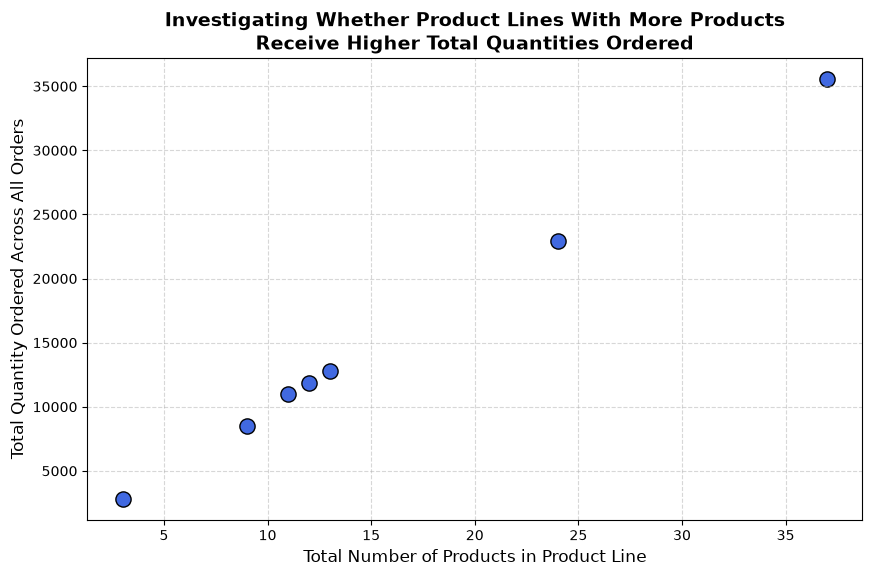

In [42]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered

plt.figure(figsize=(10,6))

plt.scatter(
    products_line_analysis["total_products"],
    products_line_analysis["total_quantity_ordered"],
    s=120,
    color="royalblue",
    edgecolor="black"
)

plt.title(
    "Investigating Whether Product Lines With More Products\n"
    "Receive Higher Total Quantities Ordered",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Total Number of Products in Product Line", fontsize=12)
plt.ylabel("Total Quantity Ordered Across All Orders", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!

I choose scatter plot because it is good for representing numerical numbers that are relate.
in this case I am comparing two numericals that are;
a. how many products  a product line has
b. how many total units sold were ordered from that product line
the scatter plot placed each producta s a dot on the graph. where in the dot it says
a. Dots higher up mean more quantity ordered
b. Dots further to the right mean more products in the product line.
By looking at the overall pattern of dots, we can visually judge whether product lines with more products tend to receive more orders. 
If the dots rise as they move right, that suggests a relationship. If they’re scattered randomly, it suggests there’s no clear connection

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [43]:
# Replace None with your code
remote_offices_data = pd.read_sql("""
SELECT 
    e.employeeNumber,
    e.FirstName AS employee_first_name,                              
    e.LastName AS employee_last_name,
    e.jobTitle AS employee_job_title,
    e.officeCode,
    CONCAT(M.firstName, ' ', M.lastName) AS supervisor_name,
    m.jobTitle AS supervisor_job_title                                                                                                                       
FROM employees e
 LEFT JOIN employees m ON e.reportsTo = m.employeeNumber                                   
 WHERE e.officeCode IN (
                        SELECT officeCode
                        FROM employees
                         GROUP BY officeCode
                         HAVING COUNT(employeeNumber) < 5
                        )
                         ORDER BY e.officeCode, e.lastName   
""", conn)
remote_offices_data                                    

,employeeNumber,employee_first_name,employee_last_name,employee_job_title,officeCode,supervisor_name,supervisor_job_title
0,1188,Julie,Firrelli,Sales Rep,2,Anthony Bow,Sales Manager (NA)
1,1216,Steve,Patterson,Sales Rep,2,Anthony Bow,Sales Manager (NA)
2,1286,Foon Yue,Tseng,Sales Rep,3,Anthony Bow,Sales Manager (NA)
3,1323,George,Vanauf,Sales Rep,3,Anthony Bow,Sales Manager (NA)
4,1625,Yoshimi,Kato,Sales Rep,5,Mami Nishi,Sales Rep
5,1621,Mami,Nishi,Sales Rep,5,Mary Patterson,VP Sales
6,1611,Andy,Fixter,Sales Rep,6,William Patterson,Sales Manager (APAC)
7,1619,Tom,King,Sales Rep,6,William Patterson,Sales Manager (APAC)
8,1612,Peter,Marsh,Sales Rep,6,William Patterson,Sales Manager (APAC)
9,1088,William,Patterson,Sales Manager (APAC),6,Mary Patterson,VP Sales


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!

I used a subquery because the main task required identifying which offices had fewer than five employees before selecting any employee details. 
The subquery groups employees by officeCode and filters those groups using HAVING COUNT(employeeNumber) < 5. 
This produces a precise list of small offices.
The main query then uses that list in its WHERE clause to return only the employees who work in those offices, along with their job and supervisor information.

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [44]:
# Replace None with your code
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [46]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

In [49]:
# Begin your code here
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [51]:
# Extract the IMDB database from the zip file
zip_file_path = 'im.db.zip'
if not os.path.exists('im.db'):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Database extracted successfully.")
else:
    print("Database already exists. No extraction needed.")

Database already exists. No extraction needed.


In [53]:
conn_imdb = sqlite3.connect('im.db')
print("Connection to the IMDB database established successfully.")


Connection to the IMDB database established successfully.


In [58]:
# Exploring the total movies
total_movies = pd.read_sql("""
SELECT COUNT(*) AS total
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019;
  """, conn_imdb).iloc[0, 0]
print(f"Total movies (2010-2019): {total_movies}")                                             

Total movies (2010-2019): 145081


In [60]:
# Finding the misisng values in the runtime and genres

missing_stats = pd.read_sql("""
    SELECT 
        SUM(CASE WHEN runtime_minutes IS NULL THEN 1 ELSE 0 END) AS missing_runtime,
        SUM(CASE WHEN genres IS NULL THEN 1 ELSE 0 END) AS missing_genres
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019;
""", conn_imdb)
print("Missing values:")
print(missing_stats)

Missing values:
   missing_runtime  missing_genres
0            30765            5359


In [62]:
#Movies per year 
moviesper_year = pd.read_sql("""
    SELECT start_year, COUNT(*) AS movie_count
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
    GROUP BY start_year
    ORDER BY start_year;
""", conn_imdb)
print("\nMovies per year:")
print(moviesper_year)


Movies per year:
   start_year  movie_count
0        2010        11849
1        2011        12900
2        2012        13787
3        2013        14709
4        2014        15589
5        2015        16243
6        2016        17272
7        2017        17504
8        2018        16849
9        2019         8379


In [63]:
#General analysis 
genre_rating_df = pd.read_sql("""
    SELECT mb.movie_id, mb.genres, mr.averagerating, mr.numvotes
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
      AND mb.genres IS NOT NULL
      AND mr.averagerating IS NOT NULL;
""", conn_imdb)

#Filtering by minimum votes (at least 100 votes)
genre_rating_df = genre_rating_df[genre_rating_df['numvotes'] >= 100]

#Splitting genres into individual rows
genre_rating_df['genres'] = genre_rating_df['genres'].str.split(',')
genre_expanded = genre_rating_df.explode('genres')
genre_expanded = genre_expanded[genre_expanded['genres'] != '']

#Aggregate per genre 
genre_stats = genre_expanded.groupby('genres').agg(
    num_movies=('movie_id', 'count'),
    avg_rating=('averagerating', 'mean')
).reset_index()
genre_stats = genre_stats.sort_values('num_movies', ascending=False)

print("\nTop 10 genres by number of movies:")
print(genre_stats.head(10))


Top 10 genres by number of movies:
         genres  num_movies  avg_rating
8         Drama       13803    6.161747
5        Comedy        8524    5.703273
22     Thriller        4432    5.380505
0        Action        3968    5.558518
13       Horror        3549    4.666948
7   Documentary        3537    7.086684
19      Romance        3475    5.981698
6         Crime        2624    5.915130
2     Adventure        1957    5.782115
16      Mystery        1589    5.628697


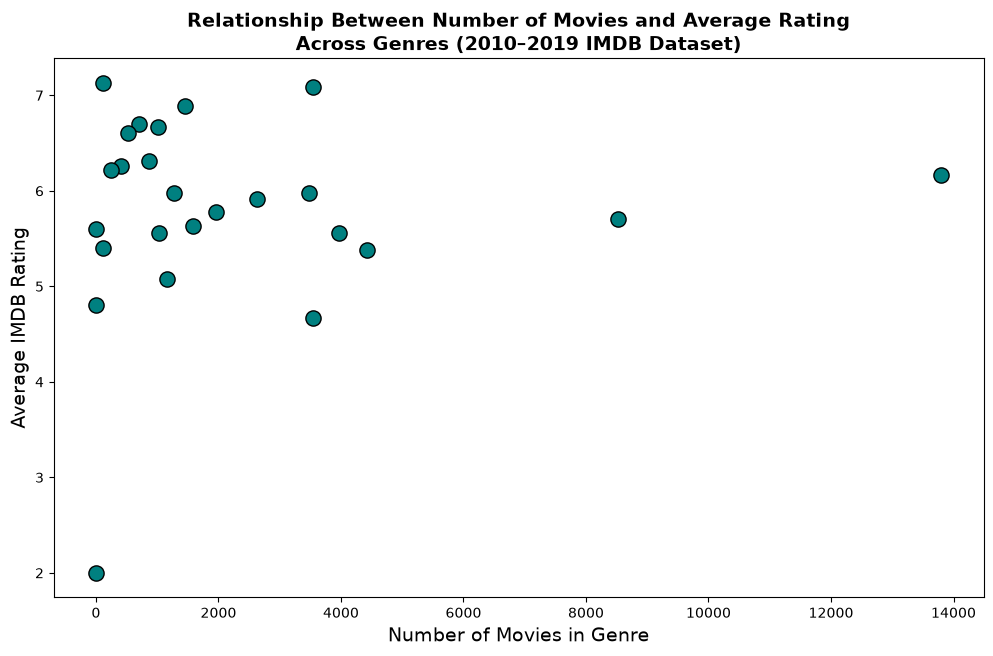

In [71]:

plt.figure(figsize=(12,7))

plt.scatter(
    genre_stats['num_movies'],
    genre_stats['avg_rating'],
    s=120,
    color='teal',
    edgecolor='black'
)

plt.title(
    "Relationship Between Number of Movies and Average Rating\n"
    "Across Genres (2010–2019 IMDB Dataset)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Number of Movies in Genre", fontsize=14)
plt.ylabel("Average IMDB Rating", fontsize=14)

plt.show()
